KÜTÜPHANELER
=

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
import datetime as dt
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [181]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


API İLE VERİ ÇEKME
=

In [183]:
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\MONSTER\.cache\kagglehub\datasets\mashlyn\online-retail-ii-uci\versions\3


In [184]:
path = r"C:\Users\MONSTER\.cache\kagglehub\datasets\mashlyn\online-retail-ii-uci\versions\3"

print(os.listdir(path))

['online_retail_II.csv']


In [185]:
file_path = r"C:\Users\MONSTER\.cache\kagglehub\datasets\mashlyn\online-retail-ii-uci\versions\3\online_retail_II.csv"

df = pd.read_csv(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


VERİ ÖN İŞLEME
=

In [187]:
df = df[df["Customer ID"].notnull()] # Müşteri numarası olmayanları silelim
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) # Tarih formatına çevirelim
df["TotalSum"] = df["Quantity"] * df["Price"] # Toplam harcamayı hesaplayalım
df = df[df["Quantity"] > 0] # Quantity eksi olanlar iade
df = df[df["Price"] > 0]

RFM TABLOSU
=

In [189]:
# Analiz günü olarak verideki son günden 1 gün sonrasını aldım
bugun = df["InvoiceDate"].max() + dt.timedelta(days=1)
 
musteri_tablosu = df.groupby("Customer ID").agg(
    Gelmeyen_Gun  = ("InvoiceDate", lambda x: (bugun - x.max()).days),
    Siparis_Sayisi = ("Invoice",     lambda x: x.nunique()),
    Toplam_Harcama = ("TotalSum",   "sum")
).reset_index()
 
print("\nMüşteri tablosu:")
print(musteri_tablosu.describe())


Müşteri tablosu:
        Customer ID  Gelmeyen_Gun  Siparis_Sayisi  Toplam_Harcama
count   5878.000000   5878.000000     5878.000000     5878.000000
mean   15315.313542    201.331916        6.289384     3018.616737
std     1715.572666    209.338707       13.009406    14737.731040
min    12346.000000      1.000000        1.000000        2.950000
25%    13833.250000     26.000000        1.000000      348.762500
50%    15314.500000     96.000000        3.000000      898.915000
75%    16797.750000    380.000000        7.000000     2307.090000
max    18287.000000    739.000000      398.000000   608821.650000


In [190]:
# 180 gündür gelmeyenlere 1 (gitti), diğerlerine 0 (hala var)
musteri_tablosu["Churn"] = (musteri_tablosu["Gelmeyen_Gun"] > 180).astype(int)
 
print("\nChurn dağılımı:")
print(musteri_tablosu["Churn"].value_counts())


Churn dağılımı:
Churn
0    3478
1    2400
Name: count, dtype: int64


In [191]:
X = musteri_tablosu[["Siparis_Sayisi", "Toplam_Harcama"]]
y = musteri_tablosu["Churn"]
 
# eğitim ve test olarak böldüm
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [192]:
# daha dengeli dağılım için
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [193]:
!pip install lightgbm

In [194]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    random_state=42
)
 
lgbm_model.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 2783, number of negative: 2783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 313
[LightGBM] [Info] Number of data points in the train set: 5566, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

LGBMClassifier(learning_rate=0.05, max_depth=5, random_state=42)

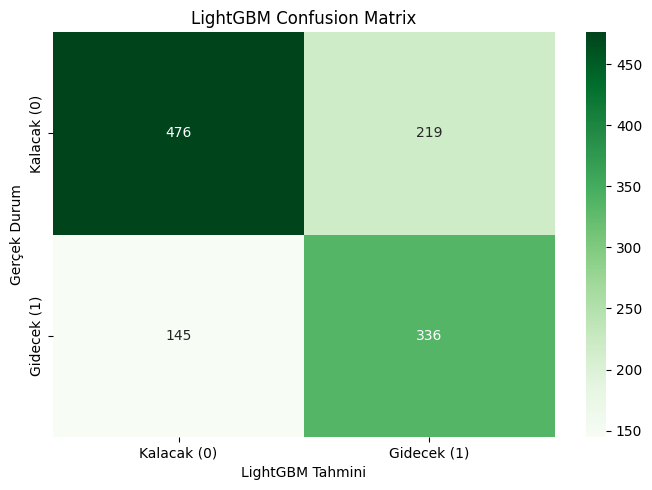

In [195]:
lgbm_pred = lgbm_model.predict(X_test)
 
# confusion matrix
cm = confusion_matrix(y_test, lgbm_pred)
 
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Kalacak (0)", "Gidecek (1)"],
            yticklabels=["Kalacak (0)", "Gidecek (1)"])
plt.xlabel("LightGBM Tahmini")
plt.ylabel("Gerçek Durum")
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.show()

In [196]:
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, lgbm_pred))


Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       695
           1       0.61      0.70      0.65       481

    accuracy                           0.69      1176
   macro avg       0.69      0.69      0.69      1176
weighted avg       0.70      0.69      0.69      1176



YÖNETİCİ NOTU — Model Çıktısına Dayalı Aksiyon Planı
=
 
Bu model, müşteri veritabanındaki yaklaşık %10'luk "riskli"
kesimi yani yakın zamanda kaybedebileceğimiz müşterileri
önceden tespit etmektedir.
 
Bu müşterileri elde tutmak için önerilen adımlar:
 
1. KİŞİSEL İLETİŞİM
   Riskli olarak işaretlenen müşterilere genel kampanya
   maili yerine kişiselleştirilmiş bir "sizi özledik" mesajı
   gönderilmeli.
 
2. ÖZEL İNDİRİM / TEŞVİK
   Bu gruba yalnızca özel bir indirim kodu ya da ücretsiz
   kargo avantajı sunulabilir. Herkese açık kampanya
   vermek yerine hedefli tutmak maliyeti düşürür.
 
3. GERİ BİLDİRİM TOPLAMA
   Neden alışveriş yapmadıklarını anlamak için kısa bir
   anket gönderilebilir. Bir kısmı fiyat, bir kısmı
   ürün çeşidi, bir kısmı kargo süresi nedeniyle
   uzaklaşmış olabilir
 
4. ÖNCE KÜÇÜK GRUPLA TEST
   Riskli müşterilerin tamamına birden müdahale etmek
   yerine önce %20'lik bir alt grup seçilip farklı
   teklifler denenmeli, sonra en iyi sonuç veren yöntem
   genele uygulanmalı.
 
NOT: Model her 10 riskli dediği müşteriden yaklaşık 4'ünde
yanılıyor (precision %61). Bu nedenle müdahale maliyeti
düşük tutulmalı; pahalı teklifler herkese değil, skorun
en yüksek olduğu ilk %5'lik dilime öncelikli verilmeli.

ÖNERİLEN UYGULAMA SIRASI:
  - İlk hafta  → Tüm riskli gruba e-posta + anket (maliyet neredeyse sıfır)
  - 2. hafta   → Geri dönüş yoksa ücretsiz kargo teklifi gönder
  - 3. hafta   → Hâlâ dönüş yoksa ve müşteri yüksek harcamalıysa indirim kodu yolla
 